<a href="https://colab.research.google.com/github/Iabhijit1/An-AI-Based-System-for-Plant-Disease-Detection-using-Deep-Neural-Networks/blob/main/Plant_Disease_Detection_using_Yolo_Algorithm_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Plant Disease Detection using Yolo Algorithm**

In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
zip_path = "/content/drive/MyDrive/YOLO_Colab_Project/Multicrop Disease Dataset.zip"
destination = "/content/dataset"

!unzip -q "{zip_path}" -d "{destination}"
print("Unzip Completed")

Unzip Completed


In [4]:
train_images_dir = '/content/dataset/Multicrop Disease Dataset/train/images'
image_files = [f for f in os.listdir(train_images_dir) if f.endswith('.jpg')]

print("TRAINING DATASET")
print(f"Total images found: {len(image_files)}")
print("First 5 Training Samples:\n")

for img_name in image_files[:5]:
    label_name = img_name.replace('.jpg', '.txt')
    print(f"Image: {img_name}")
    print(f"Label: {label_name}\n")

TRAINING DATASET
Total images found: 15310
First 5 Training Samples:

Image: Early-Leaf-Spot-1402-_jpg.rf.b38def53c481317a731c972d620d70fc.jpg
Label: Early-Leaf-Spot-1402-_jpg.rf.b38def53c481317a731c972d620d70fc.txt

Image: Late-Leaf-Spot-1162-_jpg.rf.f9aac31aebcdfc41fc0bcca98d9dc30d.jpg
Label: Late-Leaf-Spot-1162-_jpg.rf.f9aac31aebcdfc41fc0bcca98d9dc30d.txt

Image: Rust-235-_jpg.rf.2e360ebdd054698bbef5b493de0e6a40.jpg
Label: Rust-235-_jpg.rf.2e360ebdd054698bbef5b493de0e6a40.txt

Image: Yellow-and-Black-Sigatoka-1430-_jpg.rf.1e5be7ac0d5603657846d47b8c531b7f.jpg
Label: Yellow-and-Black-Sigatoka-1430-_jpg.rf.1e5be7ac0d5603657846d47b8c531b7f.txt

Image: Nutirtion-Deficiency-398-_jpg.rf.5daa7d91c349ac21436b51f9b341e9a5.jpg
Label: Nutirtion-Deficiency-398-_jpg.rf.5daa7d91c349ac21436b51f9b341e9a5.txt



In [ ]:
valid_images_dir = '/content/dataset/Multicrop Disease Dataset/valid/images'
valid_images = [f for f in os.listdir(valid_images_dir) if f.endswith('.jpg')]

print("VALIDATION DATASET DETAILS")
print(f"Total validation images found: {len(valid_images)}")
print("First 5 Validation Samples:\n")

for img_name in valid_images[:5]:
    label_name = img_name.replace('.jpg', '.txt')
    print(f"Image: {img_name}")
    print(f"Label: {label_name}\n")

VALIDATION DATASET DETAILS
Total validation images found: 4374
First 5 Validation Samples:

Image: Insect-Pest-637-_jpg.rf.88e39809703eeb9fbc6ece9aa8edfc94.jpg
Label: Insect-Pest-637-_jpg.rf.88e39809703eeb9fbc6ece9aa8edfc94.txt

Image: Rust-717-_jpg.rf.5c01d9edebb5c48d739d81d680b531f1.jpg
Label: Rust-717-_jpg.rf.5c01d9edebb5c48d739d81d680b531f1.txt

Image: sigatoka-711-_jpeg.rf.6b1125f5055eca2079bf38897a78f4c0.jpg
Label: sigatoka-711-_jpeg.rf.6b1125f5055eca2079bf38897a78f4c0.txt

Image: IMG-523-_jpg.rf.54f998e0f48d2505da32b9de2b19be64.jpg
Label: IMG-523-_jpg.rf.54f998e0f48d2505da32b9de2b19be64.txt

Image: Early-Rust-642-_jpg.rf.9c6d75a59c355895273eed0624a19f4a.jpg
Label: Early-Rust-642-_jpg.rf.9c6d75a59c355895273eed0624a19f4a.txt



In [ ]:
test_images_dir = '/content/dataset/Multicrop Disease Dataset/test/images'
test_images = [f for f in os.listdir(test_images_dir) if f.endswith('.jpg')]

print("TEST DATASET DETAILS")
print(f"Total test images found: {len(test_images)}")
print("First 5 Test Samples:\n")

for img_name in test_images[:5]:
    label_name = img_name.replace('.jpg', '.txt')
    print(f"Image: {img_name}")
    print(f"Label: {label_name}\n")

TEST DATASET DETAILS
Total test images found: 2191
First 5 Test Samples:

Image: Early-Leaf-Spot-871-_jpg.rf.182b6bdc0a0ac4d877347f1f3083e55c.jpg
Label: Early-Leaf-Spot-871-_jpg.rf.182b6bdc0a0ac4d877347f1f3083e55c.txt

Image: Nutirtion-Deficiency-928-_jpg.rf.40123fe123a521658140b426feeb10e3.jpg
Label: Nutirtion-Deficiency-928-_jpg.rf.40123fe123a521658140b426feeb10e3.txt

Image: Bacterial-Spot_-153-_jpg.rf.e612cb081dee72b196f364399dbba53a.jpg
Label: Bacterial-Spot_-153-_jpg.rf.e612cb081dee72b196f364399dbba53a.txt

Image: Flea-Beetle-80-_jpg.rf.dc9043e4b76afe0579c08e5cb603ea38.jpg
Label: Flea-Beetle-80-_jpg.rf.dc9043e4b76afe0579c08e5cb603ea38.txt

Image: Bract-Mosaic-Virus-Disease-43-_jpg.rf.4bcab98ca13445b5e7feb37d8d118802.jpg
Label: Bract-Mosaic-Virus-Disease-43-_jpg.rf.4bcab98ca13445b5e7feb37d8d118802.txt



In [ ]:
import yaml

for root, dirs, files in os.walk('/content/dataset'):
    if 'data.yaml' in files:
        actual_yaml_path = os.path.join(root, 'data.yaml')
        break

with open(actual_yaml_path, 'r') as file:
    data = file.read()

data = data.replace('C:\\Users\\abhij\\Desktop\\ABS2\\Multicrop Disease Dataset\\train\\images', '/content/dataset/Multicrop Disease Dataset/train/images')
data = data.replace('C:\\Users\\abhij\\Desktop\\ABS2\\Multicrop Disease Dataset\\valid\\images', '/content/dataset/Multicrop Disease Dataset/valid/images')
data = data.replace('C:\\Users\\abhij\\Desktop\\ABS2\\Multicrop Disease Dataset\\test\\images', '/content/dataset/Multicrop Disease Dataset/test/images')

ideal_yaml_path = '/content/dataset/Multicrop Disease Dataset/data.yaml'
with open(ideal_yaml_path, 'w') as file:
    file.write(data)

with open(ideal_yaml_path, 'r') as file:
    dataset_info = yaml.safe_load(file)

print(f"found {dataset_info['nc']} Classes:")

names = dataset_info['names']
if isinstance(names, dict):
    for class_id, class_name in names.items():
        print(f"Class {class_id}: {class_name}")
else:
    for class_id, class_name in enumerate(names):
        print(f"Class {class_id}: {class_name}")

found 30 Classes:
Class 0: banana_bract_mosaic_virus
Class 1: banana_cordana
Class 2: banana_healthy
Class 3: banana_insectpest
Class 4: banana_moko
Class 5: banana_panama
Class 6: banana_pestalotiopsis
Class 7: banana_sigatoka
Class 8: banana_yb_sigatoka
Class 9: cauliflower_Blackrot
Class 10: cauliflower_bacterial _spot _rot
Class 11: cauliflower_downy_mildew
Class 12: cauliflower_healthy
Class 13: chilli_anthracnose
Class 14: chilli_healthy
Class 15: chilli_leafcurl
Class 16: chilli_leafspot
Class 17: chilli_whitefly
Class 18: chilli_yellowish
Class 19: groundnut_early_leaf_spot
Class 20: groundnut_early_rust
Class 21: groundnut_healthy
Class 22: groundnut_late_leaf_spot
Class 23: groundnut_nutrition_deficiency
Class 24: groundnut_rust
Class 25: radish_black_leaf_spot
Class 26: radish_downey_mildew
Class 27: radish_flea_beetle
Class 28: radish_healthy
Class 29: radish_mosaic


In [5]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.0 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO('yolov8s.pt')

print("Starting 25-Epoch")
print("save to: /content/drive/MyDrive/YOLO_Colab_Project/Final_25_Epoch_Run")

results = model.train(
    data='/content/dataset/Multicrop Disease Dataset/data.yaml',
    epochs=25,
    imgsz=640,
    batch=16,
    project='/content/drive/MyDrive/YOLO_Colab_Project',
    name='Final_25_Epoch_Run'
)

In [ ]:
from ultralytics import YOLO

#Load your 25-epoch
model = YOLO('/content/drive/MyDrive/YOLO_Colab_Project/Final_25_Epoch_Run/weights/best.pt')

print("evaluation on the validation dataset")

metrics = model.val(data='/content/dataset/Multicrop Disease Dataset/Code/data.yaml')

# Print the final overall scores
# The modified visible line
print(f"Overall mAP@50: {map50:.3f}")
print(f"Overall Precision: {metrics.box.mp:.3f}")
print(f"Overall Recall: {metrics.box.mr:.3f}")

evaluation on the validation dataset
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,137,194 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1124.1±506.9 MB/s, size: 44.6 KB)
val: Scanning /content/dataset/Multicrop Disease Dataset/valid/labels.cache... 4374 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4374/4374 1.1Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 274/274 4.2it/s 1:05
                   all       4374       7881      0.754      0.722      0.749      0.524
banana_bract_mosaic_virus         80         80      0.977      0.988      0.983      0.883
        banana_cordana        111        482      0.841      0.902      0.941      0.545
        banana_healthy        216        218      0.982      0.983      0.994        0.8
     banana_insectpest        139        359      0.651      0.317

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
testing on images

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/4374 /content/dataset/Multicrop Disease Dataset/valid/images/Anthracnose-14-_jpg.rf.36ca621693f8b8dac6d38ebd02abef79.jpg:

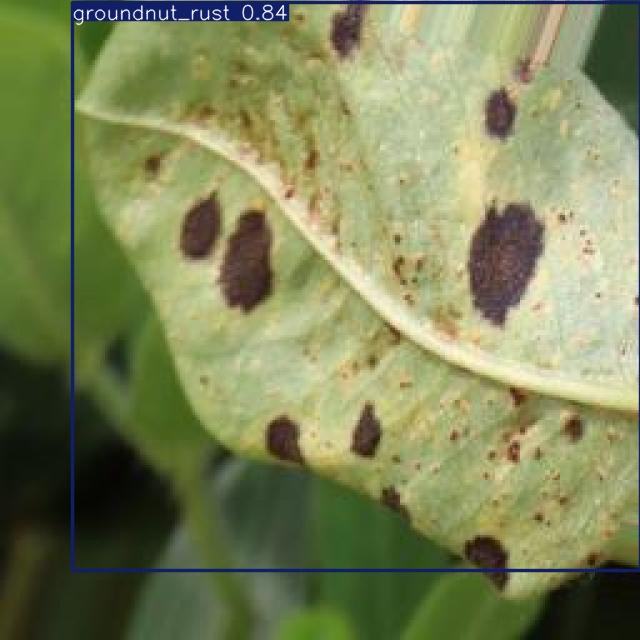

In [ ]:
from ultralytics import YOLO
import glob
from IPython.display import Image, display

model = YOLO('/content/drive/MyDrive/YOLO_Colab_Project/Final_25_Epoch_Run/weights/best.pt')

print("testing on images")

results = model.predict(
    source='/content/dataset/Multicrop Disease Dataset/valid/images',
    save=True,
    project='/content/drive/MyDrive/YOLO_Colab_Project',
    name='AI_Predictions'
)

print("\nResult:")

result_images = glob.glob('/content/drive/MyDrive/YOLO_Colab_Project/AI_Predictions/*.jpg')
display(Image(filename=result_images[0], width=600))

**prediction Test**

In [ ]:
!pip install gradio

Saving Black-Leaf-Spot-40-_jpg.rf.64030a96489ddf03751d70b526ff72da.jpg to Black-Leaf-Spot-40-_jpg.rf.64030a96489ddf03751d70b526ff72da.jpg

Scanning Black-Leaf-Spot-40-_jpg.rf.64030a96489ddf03751d70b526ff72da.jpg

image 1/1 /content/Black-Leaf-Spot-40-_jpg.rf.64030a96489ddf03751d70b526ff72da.jpg: 640x640 1 radish_black_leaf_spot, 1045.1ms
Speed: 4.6ms preprocess, 1045.1ms inference, 5.5ms postprocess per image at shape (1, 3, 640, 640)


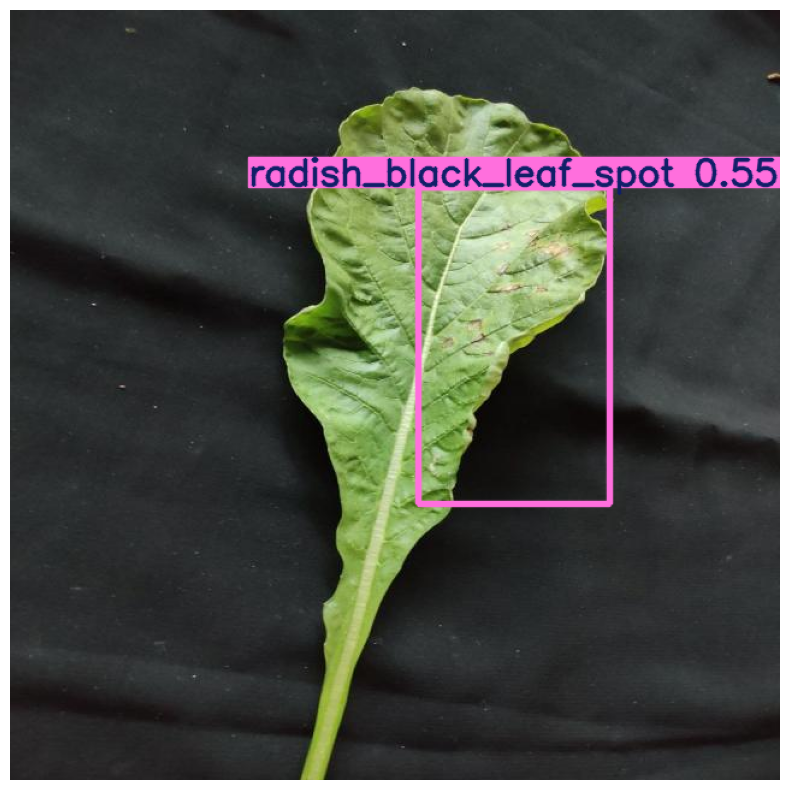

In [ ]:
from google.colab import files
import cv2
from matplotlib import pyplot as plt

model = YOLO('/content/drive/MyDrive/YOLO_Colab_Project/Final_25_Epoch_Run/weights/best.pt')
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nScanning {filename}")

    results = model.predict(source=filename, conf=0.50)

    annotated_img = results[0].plot(line_width=3)


    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.imshow(annotated_img_rgb)
    plt.axis('off')
    plt.show()

    os.remove(filename)